# ClinIQ — Clinical Patient Risk Intelligence System
**Stack:** XGBoost · TF-IDF · SHAP · Sentence-BERT · FAISS · RoBERTa QA · Fairlearn · Streamlit

## 0. Install dependencies

In [1]:
%pip install xgboost shap faiss-cpu sentence-transformers transformers torch
%pip install scikit-learn pandas numpy matplotlib seaborn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 16.1 MB/s eta 0:00:00


In [2]:
!python -m pip install --upgrade pip setuptools wheel
!pip install --prefer-binary scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.5 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.


In [3]:
%pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 77.4 MB/s  0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fairlearn]


In [4]:
import fairlearn
print(fairlearn.__version__)

0.13.0


## 1. Imports & setup

In [5]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score
from xgboost import XGBClassifier
import shap
import faiss
from sentence_transformers import SentenceTransformer
from fairlearn.metrics import MetricFrame
print("Fairlearn import OK")

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

RISK_LABELS = ['Low Risk', 'Medium Risk', 'High Risk']
RISK_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']
print('Imports OK')

Fairlearn import OK
Imports OK


## 2. Load MTSamples dataset

In [6]:
df_raw = pd.read_csv('/content/mtsamples.csv')
print('Raw shape:', df_raw.shape)
print('Columns:', list(df_raw.columns))
df_raw.head(3)

Raw shape: (4999, 6)
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [7]:
# Standardise column names
col_map = {}
for col in df_raw.columns:
    lc = col.lower().strip()
    if 'transcript' in lc:    col_map[col] = 'transcription'
    elif 'special' in lc:     col_map[col] = 'medical_specialty'
    elif 'description' in lc: col_map[col] = 'description'
df_raw = df_raw.rename(columns=col_map)

df = df_raw[['transcription', 'medical_specialty']].dropna(subset=['transcription']).copy()
df['transcription']     = df['transcription'].astype(str)
df['medical_specialty'] = df['medical_specialty'].astype(str).str.strip()
print('After dropna:', df.shape)
df['medical_specialty'].value_counts().head(15)

After dropna: (4966, 2)


,count
medical_specialty,
Surgery,1088
Consult - History and Phy.,516
Cardiovascular / Pulmonary,371
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,224
Neurology,223
SOAP / Chart / Progress Notes,166


## 3. Risk label engineering
`2 = High Risk` (cardiovascular, surgical, neuro) · `1 = Medium` · `0 = Low Risk` (outpatient/routine)

In [8]:
HIGH_RISK = {
    'Cardiovascular / Pulmonary','Neurology','Neurosurgery',
    'Orthopedic','Surgery','Urology','Oncology',
    'Hematology - Oncology','Radiology','Emergency Room Reports',
    'ICU - Intensive Care Unit','Nephrology','Gastroenterology'
}
LOW_RISK = {
    'Allergy / Immunology','Cosmetic / Plastic Surgery',
    'Dentistry','Dermatology','ENT - Otolaryngology',
    'Letters','Office Notes','Ophthalmology','Pediatrics - Neonatal',
    'Physical Medicine - Rehabilitation','Podiatry',
    'SOAP / Chart / Progress Notes','Speech - Language'
}

def assign_risk(spec):
    if spec in HIGH_RISK: return 2
    if spec in LOW_RISK:  return 0
    return 1

df['risk_label'] = df['medical_specialty'].apply(assign_risk)
print(df['risk_label'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
df['risk_label'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=RISK_COLORS, edgecolor='white', width=0.5)
ax.set_xticklabels(RISK_LABELS, rotation=0)
ax.set_title('Risk Label Distribution', fontweight='bold')
ax.set_facecolor('#f8f9fa'); fig.patch.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

risk_label
0     634
1    1302
2    3030
Name: count, dtype: int64


## 4. Text preprocessing & demographic inference

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def infer_gender(text):
    he  = len(re.findall(r'\bhe\b|\bhim\b|\bhis\b', text))
    she = len(re.findall(r'\bshe\b|\bher\b|\bhers\b', text))
    return 'female' if she > he else ('male' if he > she else 'unknown')

def infer_age_group(text):
    nums = re.findall(r'(\d+)[\s-]*(year|yr)', text)
    ages = [int(n) for n, _ in nums if int(n) < 120]
    if not ages: return 'unknown'
    a = ages[0]
    return 'pediatric' if a < 18 else ('young_adult' if a < 40 else ('middle_aged' if a < 65 else 'elderly'))

df['clean_text'] = df['transcription'].apply(clean_text)
df['gender']     = df['clean_text'].apply(infer_gender)
df['age_group']  = df['clean_text'].apply(infer_age_group)
print('Gender:\n', df['gender'].value_counts())
print('\nAge group:\n', df['age_group'].value_counts())

Gender:
 gender
female     1834
male       1652
unknown    1480
Name: count, dtype: int64

Age group:
 age_group
unknown        2293
middle_aged     980
elderly         695
young_adult     557
pediatric       441
Name: count, dtype: int64


## 5. Train / test split & TF-IDF vectorisation

In [10]:
X_text = df['clean_text'].values
y      = df['risk_label'].values

(X_train_txt, X_test_txt,
 y_train, y_test,
 g_train, g_test,
 a_train, a_test) = train_test_split(
    X_text, y, df['gender'].values, df['age_group'].values,
    test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
X_train = vectorizer.fit_transform(X_train_txt)
X_test  = vectorizer.transform(X_test_txt)
feature_names = np.array(vectorizer.get_feature_names_out())
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (3972, 1000)  |  Test: (994, 1000)


## 6. XGBoost training & evaluation

In [11]:
clf = XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    gamma=0.1, eval_metric='mlogloss', random_state=42, verbosity=0
)
clf.fit(X_train, y_train)

y_pred       = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f'Accuracy:     {acc:.4f}')
print(f'Weighted AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=RISK_LABELS))

Accuracy:     0.6066
Weighted AUC: 0.7845

              precision    recall  f1-score   support

    Low Risk       0.16      0.15      0.15       127
 Medium Risk       0.51      0.49      0.50       261
   High Risk       0.73      0.75      0.74       606

    accuracy                           0.61       994
   macro avg       0.47      0.46      0.47       994
weighted avg       0.60      0.61      0.60       994



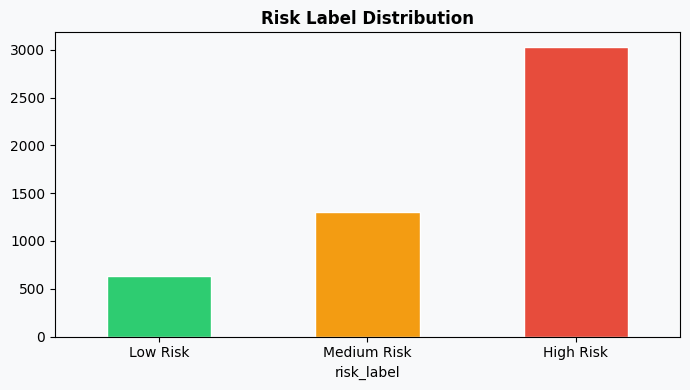

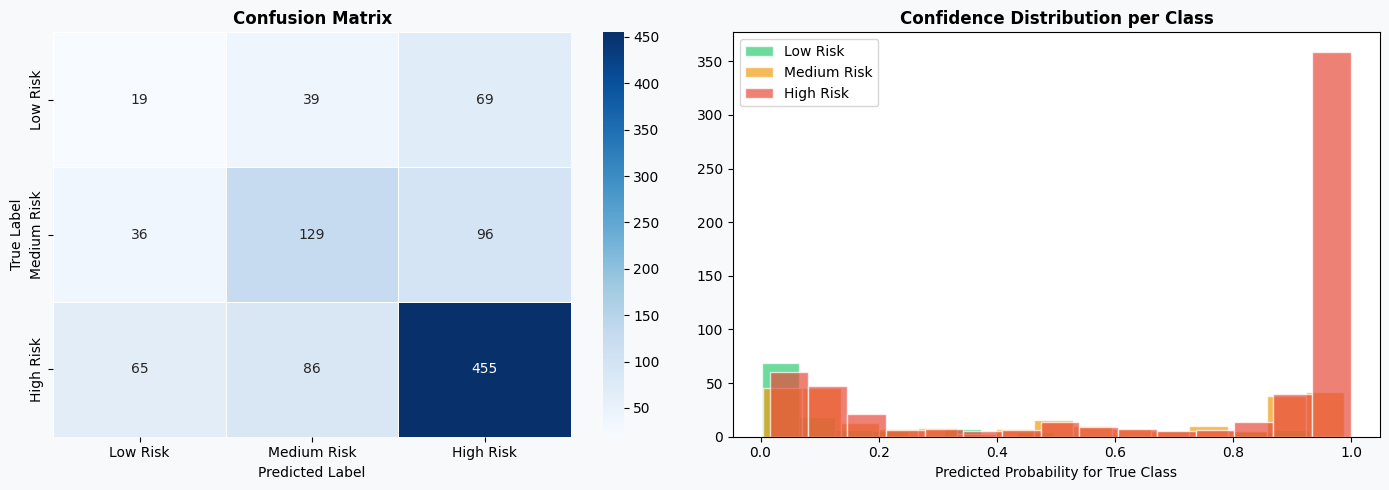

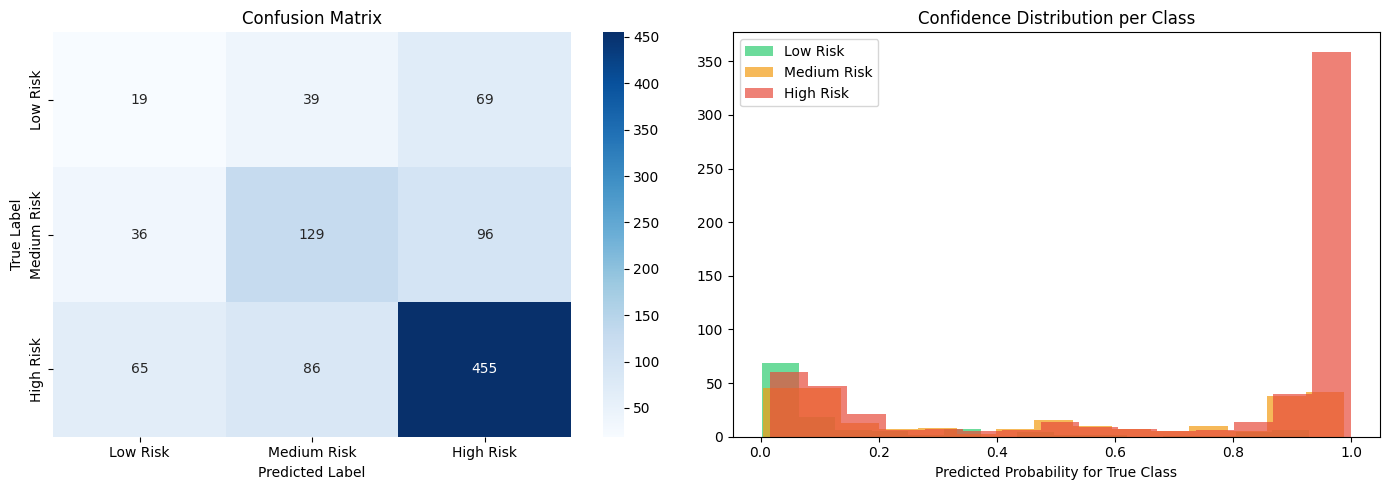

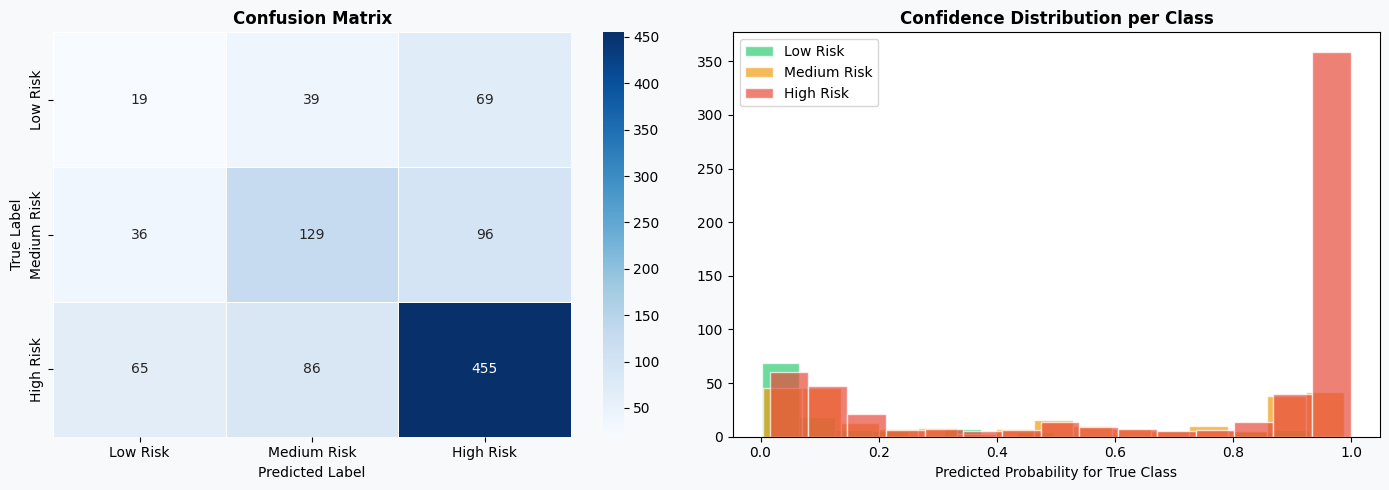

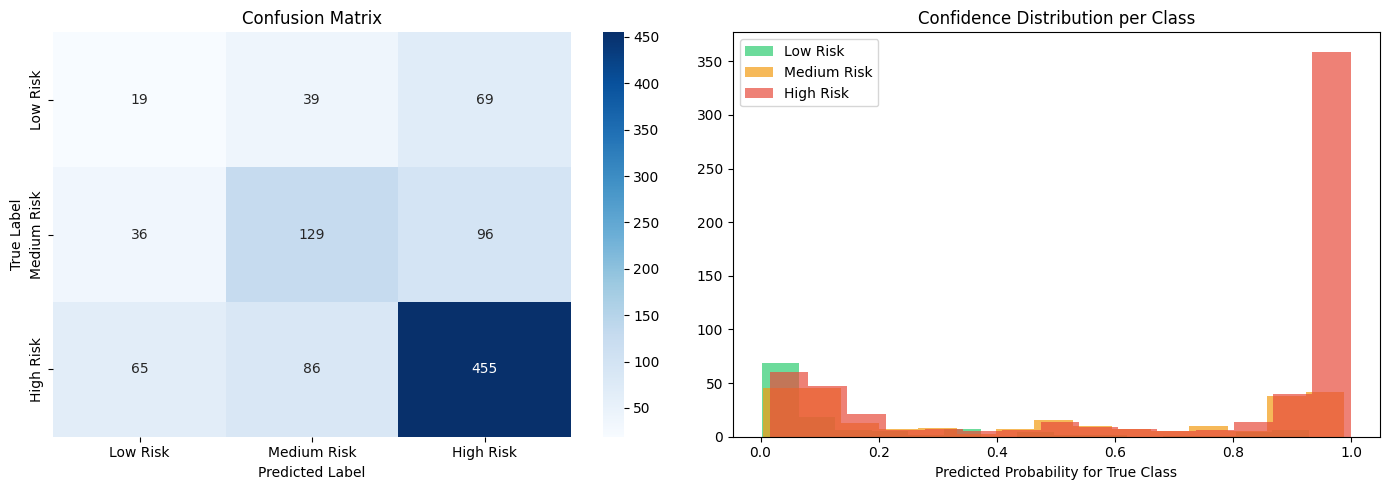

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=RISK_LABELS, yticklabels=RISK_LABELS)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

for lvl, lbl, col in zip(range(3), RISK_LABELS, RISK_COLORS):
    mask = (y_test == lvl)
    axes[1].hist(y_pred_proba[mask, lvl], bins=15, alpha=0.7,
                 label=lbl, color=col)
axes[1].set_title('Confidence Distribution per Class')
axes[1].set_xlabel('Predicted Probability for True Class')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. SHAP TreeExplainer — interpretability

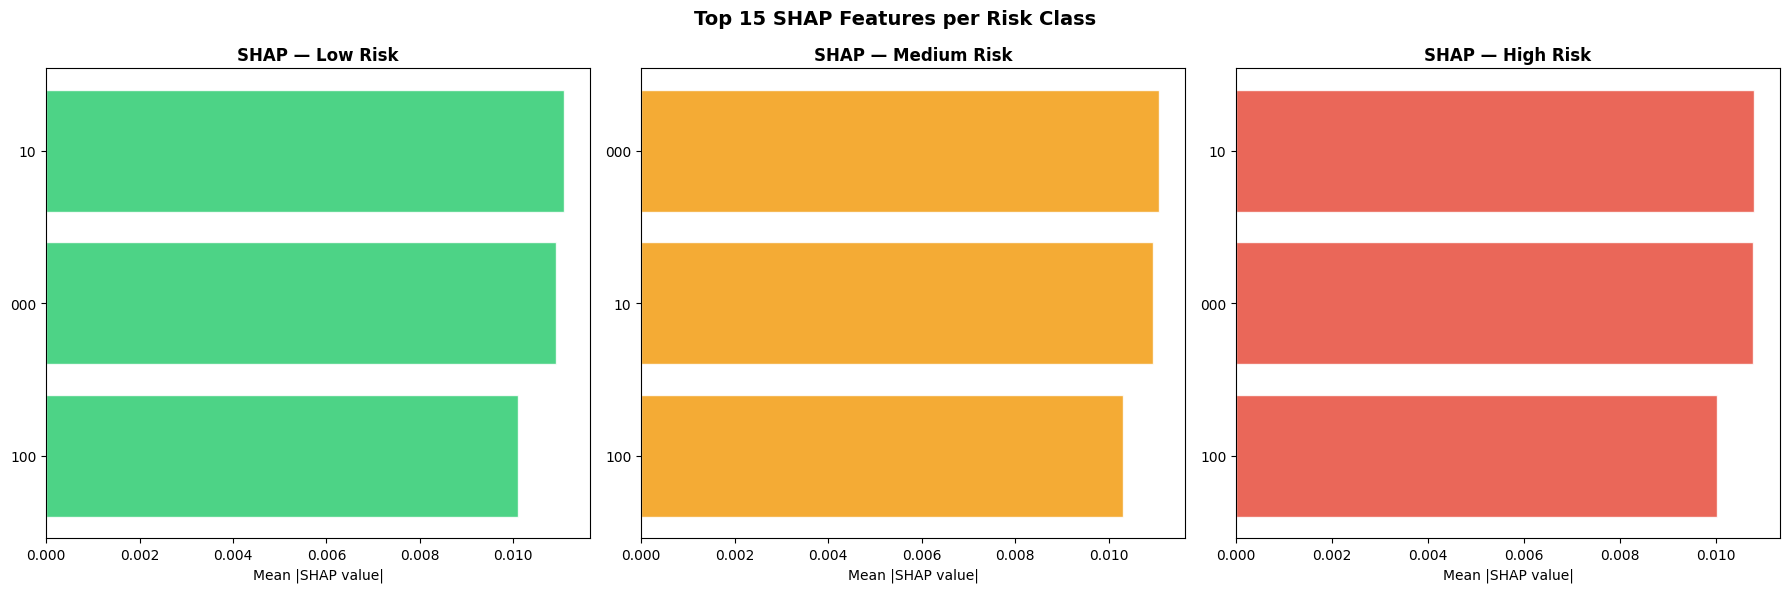

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import shap

explainer = shap.TreeExplainer(clf)
N_shap = min(300, X_test.shape[0])
shap_sample = X_test[:N_shap].toarray()
shap_values = explainer.shap_values(shap_sample)  # list[3] of (N, features)

# Plot top 15 SHAP features per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for cls in range(3):
    mean_abs = np.abs(shap_values[cls]).mean(axis=0)
    top15 = np.argsort(mean_abs)[-15:]
    axes[cls].barh(feature_names[top15], mean_abs[top15],
                   color=RISK_COLORS[cls], alpha=0.85, edgecolor='white')
    axes[cls].set_title(f'SHAP — {RISK_LABELS[cls]}', fontsize=12, fontweight='bold')
    axes[cls].set_xlabel('Mean |SHAP value|')

plt.suptitle('Top 15 SHAP Features per Risk Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

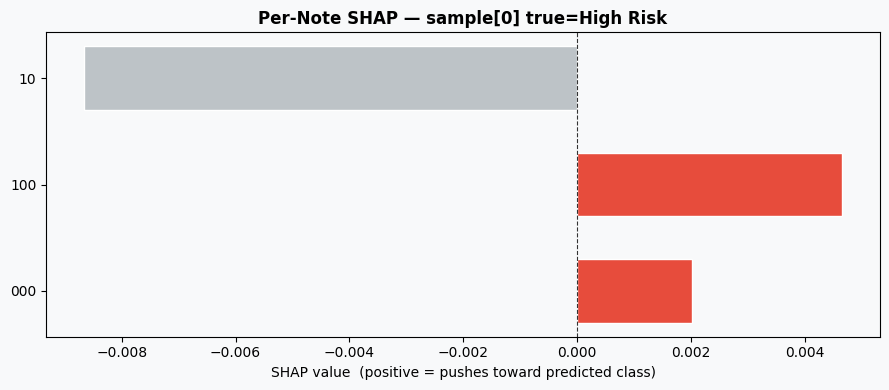

In [17]:
# Per-note SHAP waterfall (sample index 0)
note_idx = 0
sv = shap_values[y_test[note_idx]][note_idx]
top_idx = np.argsort(np.abs(sv))[-12:][::-1]
vals, names = sv[top_idx], feature_names[top_idx]

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [RISK_COLORS[y_test[note_idx]] if v > 0 else '#bdc3c7' for v in vals]
ax.barh(names[::-1], vals[::-1], color=bar_colors[::-1], edgecolor='white', height=0.6)
ax.axvline(0, color='#333', linewidth=0.8, linestyle='--')
ax.set_xlabel('SHAP value  (positive = pushes toward predicted class)')
ax.set_title(f'Per-Note SHAP — sample[{note_idx}] true={RISK_LABELS[y_test[note_idx]]}', fontweight='bold')
ax.set_facecolor('#f8f9fa'); fig.patch.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('results/shap_single_note.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Fairlearn Bias Audit

In [18]:
metrics_dict = {
    'accuracy':  accuracy_score,
    'precision': lambda yt, yp: precision_score(yt, yp, average='weighted', zero_division=0),
    'recall':    lambda yt, yp: recall_score(yt, yp, average='weighted', zero_division=0),
}

mask_g = g_test != 'unknown'
mask_a = a_test != 'unknown'

mf_gender = MetricFrame(
    metrics=metrics_dict, y_true=y_test[mask_g], y_pred=y_pred[mask_g],
    sensitive_features=g_test[mask_g]
)
mf_age = MetricFrame(
    metrics=metrics_dict, y_true=y_test[mask_a], y_pred=y_pred[mask_a],
    sensitive_features=a_test[mask_a]
)

print('=== Gender MetricFrame ===')
display(mf_gender.by_group.round(4))
print('Max gap:', mf_gender.difference().round(4))
print()
print('=== Age MetricFrame ===')
display(mf_age.by_group.round(4))
print('Max gap:', mf_age.difference().round(4))

=== Gender MetricFrame ===


,accuracy,precision,recall
sensitive_feature_0,,,
female,0.4985,0.4880,0.4985
male,0.5977,0.6075,0.5977


Max gap: accuracy     0.0991
precision    0.1195
recall       0.0991
dtype: float64

=== Age MetricFrame ===


,accuracy,precision,recall
sensitive_feature_0,,,
elderly,0.5515,0.5428,0.5515
middle_aged,0.5533,0.5525,0.5533
pediatric,0.5952,0.5952,0.5952
young_adult,0.5776,0.5922,0.5776


Max gap: accuracy     0.0438
precision    0.0524
recall       0.0438
dtype: float64


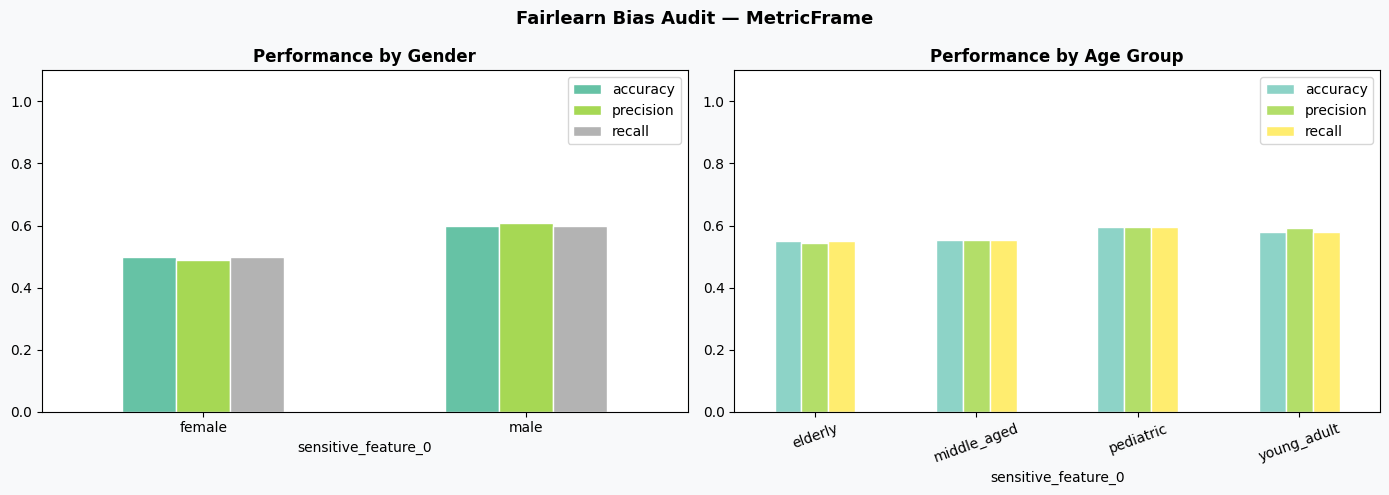

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')
mf_gender.by_group.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Performance by Gender', fontweight='bold')
axes[0].set_ylim(0, 1.1); axes[0].tick_params(axis='x', rotation=0)
mf_age.by_group.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Performance by Age Group', fontweight='bold')
axes[1].set_ylim(0, 1.1); axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('Fairlearn Bias Audit — MetricFrame', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. RAG Pipeline — Sentence-BERT + FAISS

In [20]:
# Build balanced RAG corpus (up to 200 notes per class)
rag_df = df.groupby('risk_label').apply(
    lambda g: g.sample(min(200, len(g)), random_state=42)
).reset_index(drop=True)
rag_texts = rag_df['transcription'].tolist()
rag_specs = rag_df['medical_specialty'].tolist()
rag_risks = rag_df['risk_label'].tolist()
print(f'RAG corpus: {len(rag_texts)} notes')

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embed_model.encode(
    rag_texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True
).astype('float32')
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
print(f'FAISS index: {index.ntotal} vectors, dim={embeddings.shape[1]}')

RAG corpus: 600 notes


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

FAISS index: 600 vectors, dim=384


In [21]:
# RAG retrieval demo
question = 'What symptoms did the patient present with?'
q_emb = embed_model.encode([question], convert_to_numpy=True).astype('float32')
faiss.normalize_L2(q_emb)
scores, ids = index.search(q_emb, 3)

print(f'Query: "{question}"\n')
for rank, (score, did) in enumerate(zip(scores[0], ids[0])):
    print(f'[{rank+1}] sim={score:.3f} | {rag_specs[did]} | {RISK_LABELS[rag_risks[did]]}')
    print(f'    {rag_texts[did][:250]}...\n')

Query: "What symptoms did the patient present with?"

[1] sim=0.637 | Consult - History and Phy. | Medium Risk
    HISTORY OF PRESENT ILLNESS: , This is a 12-year-old male, who was admitted to the Emergency Department, who fell off his bicycle, not wearing a helmet, a few hours ago.  There was loss of consciousness.  The patient complains of neck pain.,CHRONIC/IN...

[2] sim=0.623 | General Medicine | Medium Risk
    REVIEW OF SYSTEMS:,CONSTITUTIONAL:  Patient denies fevers, chills, sweats and weight changes.,EYES:  Patient denies any visual symptoms.,EARS, NOSE, AND THROAT:  No difficulties with hearing.  No symptoms of rhinitis or sore throat.,CARDIOVASCULAR:  ...

[3] sim=0.612 | General Medicine | Medium Risk
    CHIEF COMPLAINT: , Nausea and feeling faint.,HPI:  ,The patient is a 74-year-old white female brought in by husband.  The patient is a vague historian at times.  She reports her appetite has been fair over the last several days.  Today, she complains...



In [22]:
# RoBERTa QA on top retrieved context
from transformers import pipeline as hf_pipeline
qa = hf_pipeline('question-answering', model='deepset/roberta-base-squad2', device=-1)
context = ' '.join([rag_texts[i][:600] for i in ids[0]])
ans = qa(question=question, context=context)
print('Question:', question)
print('Answer:  ', ans['answer'])
print('Score:   ', round(ans['score'], 4))

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Question: What symptoms did the patient present with?
Answer:   urinary
Score:    0.0004


## 10. Save all artefacts → cliniq_artefacts.pkl

In [23]:
art = {
    'clf':          clf,
    'vectorizer':   vectorizer,
    'feature_names':feature_names,
    'acc':          acc,
    'auc':          auc,
    'y_test':       y_test,
    'y_pred':       y_pred,
    'y_pred_proba': y_pred_proba,
    'rag_texts':    rag_texts,
    'rag_specs':    rag_specs,
    'rag_risks':    rag_risks,
    'mf_gender':    mf_gender,
    'mf_age':       mf_age,
    'faiss_index':  index,
}
with open('cliniq_artefacts.pkl', 'wb') as f:
    pickle.dump(art, f)
print('cliniq_artefacts.pkl saved!')
print('Run the dashboard with:  streamlit run app.py')

cliniq_artefacts.pkl saved!
Run the dashboard with:  streamlit run app.py


## 11. Full results dashboard (6-panel plot)

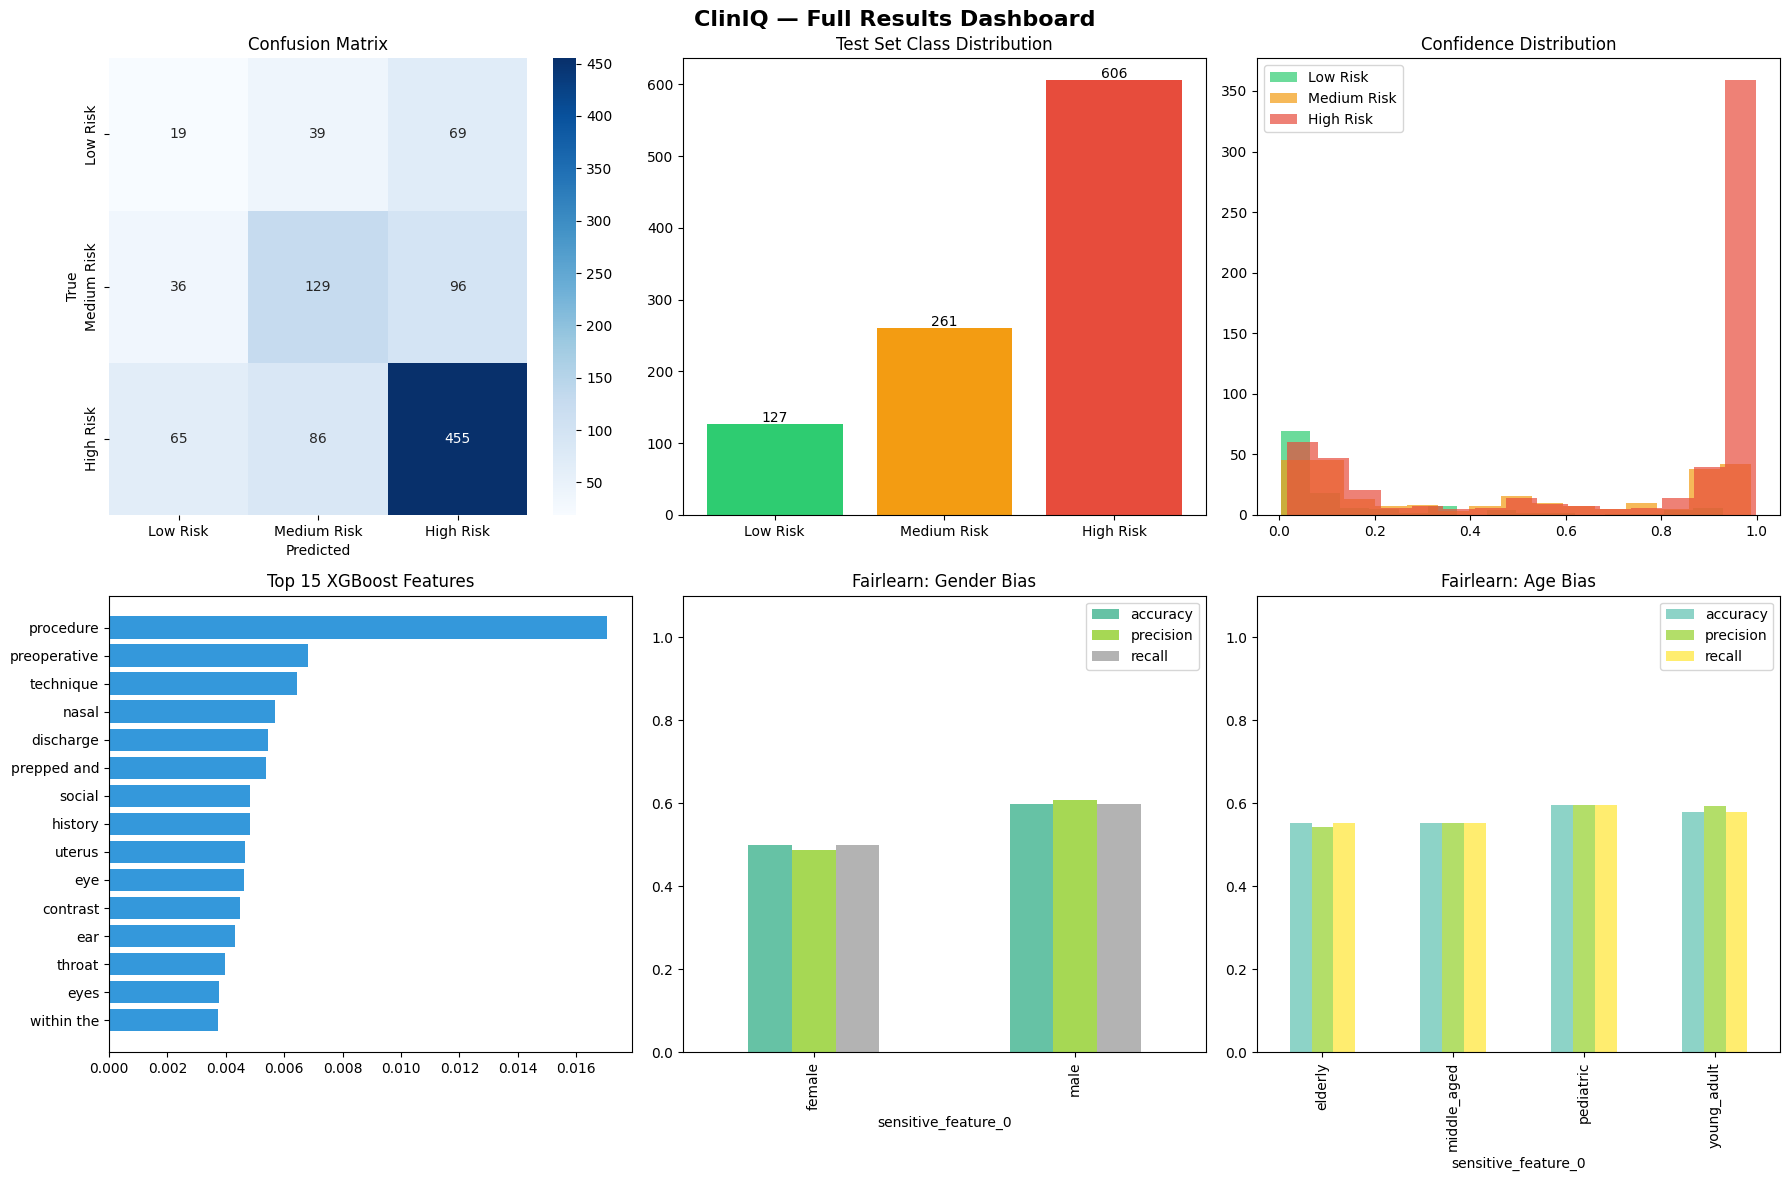

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Feature importance and confusion matrix
imp   = clf.feature_importances_
top15 = np.argsort(imp)[-15:]
cm    = confusion_matrix(y_test, y_pred)

# Create dashboard layout
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=RISK_LABELS, yticklabels=RISK_LABELS)
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('True')
axes[0,0].set_xlabel('Predicted')

# Test set class distribution
cls_counts = [np.sum(y_test==i) for i in range(3)]
bars = axes[0,1].bar(RISK_LABELS, cls_counts, color=RISK_COLORS)
axes[0,1].set_title('Test Set Class Distribution')
for b, c in zip(bars, cls_counts):
    axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+3, str(c), ha='center')

# Confidence distribution
for lvl, lbl, col in zip(range(3), RISK_LABELS, RISK_COLORS):
    mask = (y_test == lvl)
    axes[0,2].hist(y_pred_proba[mask, lvl], bins=15, alpha=0.7, label=lbl, color=col)
axes[0,2].set_title('Confidence Distribution')
axes[0,2].legend()

# Top features
axes[1,0].barh(feature_names[top15], imp[top15], color='#3498db')
axes[1,0].set_title('Top 15 XGBoost Features')

# Fairlearn bias plots
mf_gender.by_group.plot(kind='bar', ax=axes[1,1], colormap='Set2')
axes[1,1].set_title('Fairlearn: Gender Bias')
axes[1,1].set_ylim(0, 1.1)

mf_age.by_group.plot(kind='bar', ax=axes[1,2], colormap='Set3')
axes[1,2].set_title('Fairlearn: Age Bias')
axes[1,2].set_ylim(0, 1.1)

# Dashboard styling
plt.suptitle('ClinIQ — Full Results Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()